*** 1. Problem Definition ***

We aim to predict the wildfire events likelihood that the fire comes within 5 km of an evacuation zone at different future time horizon: [prob_12h prob_24h prob_48h prob_72h]


Target Y:  
* time_to_hit_hours = time until the wildfire reaches the zone
* event(wildfire) = 1 if it reached, 0 if censored

Feature X: test and train data columns


Our goal is to imporve the metrics:  
* HybridScore = 0.3 × C-inde x+ 0.7 × (1 − Weighted Brier Score)

In [1]:
import pandas as pd
import numpy as np

# Load Data
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

# check data stucture
print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()


Train shape: (221, 37)
Test shape: (95, 35)


,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


In [2]:
# Check missing vals
missing_train = train.isnull().sum().sum()
missing_test = test.isnull().sum().sum()

print("Total missing values in train:", missing_train)
print("Total missing values in test:", missing_test)

Total missing values in train: 0
Total missing values in test: 0


In [3]:
# targets
Y_time = train["time_to_hit_hours"]
Y_event = train["event"]

# Feature columns (exclude ID and target variables)
FEATURE_COLS = [
    col for col in train.columns
    if col not in ["event_id", "time_to_hit_hours", "event"]
]

X = train[FEATURE_COLS]
X_test = test[FEATURE_COLS]

print("Total number of features:", len(FEATURE_COLS))

Total number of features: 34


In [4]:
train.shape
train.head()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


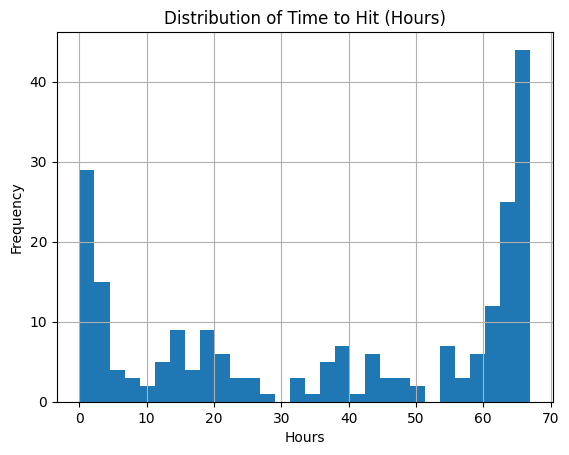

In [5]:
# Visualize 
import matplotlib.pyplot as plt

train["time_to_hit_hours"].hist(bins=30)
plt.title("Distribution of Time to Hit (Hours)")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.show()


### 2. DATA UNDERSTANDING AND AUDIT



In [6]:
# some basic stats on the datasets
# Event distribution
print(f"\nEvent distribution:")
event_counts = train["event"].value_counts().sort_index()
print(f"  Censored (0): {event_counts.get(0, 0)} ({event_counts.get(0, 0)/len(train)*100:.1f}%)")
print(f"  Hit (1): {event_counts.get(1, 0)} ({event_counts.get(1, 0)/len(train)*100:.1f}%)")

# Time to hit stats (for events that hit)
hits = train[train["event"] == 1]
print(f"\nTime-to-hit distribution (hits only, n={len(hits)}):")
print(f"  Mean: {hits['time_to_hit_hours'].mean():.1f}h")
print(f"  Median: {hits['time_to_hit_hours'].median():.1f}h")
print(f"  Min: {hits['time_to_hit_hours'].min():.1f}h")
print(f"  Max: {hits['time_to_hit_hours'].max():.1f}h")
print(f"  25th: {hits['time_to_hit_hours'].quantile(0.25):.1f}h")
print(f"  75th: {hits['time_to_hit_hours'].quantile(0.75):.1f}h")

# Horizon feasibility
print(f"\nHits by horizon (feasibility check):")
for h in [12, 24, 48, 72]:
    n_hits = ((train["time_to_hit_hours"] <= h) & (train["event"] == 1)).sum()
    print(f"  ≤{h:2d}h: {n_hits:3d} hits ({n_hits/len(train)*100:.1f}% of dataset)")



Event distribution:
  Censored (0): 152 (68.8%)
  Hit (1): 69 (31.2%)

Time-to-hit distribution (hits only, n=69):
  Mean: 10.0h
  Median: 3.5h
  Min: 0.0h
  Max: 66.9h
  25th: 0.9h
  75th: 14.3h

Hits by horizon (feasibility check):
  ≤12h:  49 hits (22.2% of dataset)
  ≤24h:  63 hits (28.5% of dataset)
  ≤48h:  66 hits (29.9% of dataset)
  ≤72h:  69 hits (31.2% of dataset)


In [7]:
# Missing values audit
FEATURE_COLS = [col for col in train.columns 
                if col not in ["event_id", "time_to_hit_hours", "event"]]

missing_train = train[FEATURE_COLS].isnull().sum()
missing_test = test[FEATURE_COLS].isnull().sum()

if missing_train.sum() == 0:
    print("\nNo missing values in training features.")
else:
    print("\nMissing values in training features:")
    print(missing_train[missing_train > 0].sort_values(ascending=False))

if missing_test.sum() == 0:
    print("\nNo missing values in test features.")
else:
    print("\nMissing values in test features:")
    print(missing_test[missing_test > 0].sort_values(ascending=False))
    
# check for duplicates
n_dup = train.duplicated(subset=FEATURE_COLS).sum()
print(f"\nNumber of duplicate rows in training data: {n_dup}")


No missing values in training features.

No missing values in test features.

Number of duplicate rows in training data: 0


In [8]:
# data leakage check, features that are highly correlated with the target
# Correlation with target time (suspicious if too high)
print("\nTop 10 features correlated with time_to_hit:")
correlations = train[FEATURE_COLS].corrwith(train["time_to_hit_hours"]).abs()
top_corr = correlations.sort_values(ascending=False).head(10)
for col, corr in top_corr.items():
    flag = "WARNING " if corr > 0.7 else "  "
    print(f"{flag} {col:40s}: {corr:.3f}")

# Perfect separation check
print("\nChecking for perfect event separation:")
n_perfect = 0
for col in FEATURE_COLS:
    hit_min = train[train["event"] == 1][col].min()
    cens_max = train[train["event"] == 0][col].max()
    if hit_min > cens_max:
        print(f"{col}: Hits always > Censored")
        n_perfect += 1
        
if n_perfect == 0:
    print("No perfect separation found")


Top 10 features correlated with time_to_hit:
   low_temporal_resolution_0_5h            : 0.442
   dt_first_last_0_5h                      : 0.435
   num_perimeters_0_5h                     : 0.392
   spread_bearing_cos                      : 0.370
   alignment_abs                           : 0.367
   spread_bearing_deg                      : 0.336
   dist_min_ci_0_5h                        : 0.325
   log1p_growth                            : 0.317
   dist_fit_r2_0_5h                        : 0.284
   log_area_ratio_0_5h                     : 0.228

Checking for perfect event separation:
No perfect separation found


In [9]:
# outliers - flag extreme outliers (5 IQR rule)
outlier_features = []
for col in FEATURE_COLS:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 5 * IQR
    upper = Q3 + 5 * IQR
    
    n_outliers = ((train[col] < lower) | (train[col] > upper)).sum()
    pct_outliers = n_outliers / len(train) * 100
    
    if pct_outliers > 5:  # Only flag if >5% are outliers
        outlier_features.append((col, n_outliers, pct_outliers))

if outlier_features:
    print(f"\nFeatures with >5% extreme outliers:")
    for col, n, pct in sorted(outlier_features, key=lambda x: x[2], reverse=True)[:10]:
        print(f"   {col:40s}: {n:3d} ({pct:5.1f}%)")
else:
    print("\nNo features with >5% extreme outliers")



Features with >5% extreme outliers:
   alignment_cos                           :  61 ( 27.6%)
   dist_slope_ci_0_5h                      :  52 ( 23.5%)
   alignment_abs                           :  45 ( 20.4%)
   dist_accel_m_per_h2                     :  35 ( 15.8%)
   area_growth_abs_0_5h                    :  25 ( 11.3%)
   area_growth_rel_0_5h                    :  25 ( 11.3%)
   area_growth_rate_ha_per_h               :  25 ( 11.3%)
   log_area_ratio_0_5h                     :  25 ( 11.3%)
   relative_growth_0_5h                    :  25 ( 11.3%)
   radial_growth_m                         :  25 ( 11.3%)


### 3. DATA PREP:

In [10]:
# Create binary labels for different horizons:
HORIZONS = [12, 24, 48, 72]

for horizon in HORIZONS:
    # Binary label: fire hit within this time window
    # Only label as 1 if event occurred AND time <= horizon
    train[f"hit_by_{horizon}h"] = (
        (train["event"] == 1) & (train["time_to_hit_hours"] <= horizon)
    ).astype(int)
    
    n_hits = train[f"hit_by_{horizon}h"].sum()
    print(f"\nHorizon {horizon:2d}h: {n_hits:3d} positives ({n_hits/len(train)*100:.1f}%)")
    
    FEATURE_COLS = [col for col in train.columns
                    if col not in ["event_id", "time_to_hit_hours", "event"] +
                    [f"hit_by_{h}h" for h in HORIZONS]]
    
    
print(f"\n Final feature count: {len(FEATURE_COLS)}")



Horizon 12h:  49 positives (22.2%)

Horizon 24h:  63 positives (28.5%)

Horizon 48h:  66 positives (29.9%)

Horizon 72h:  69 positives (31.2%)

 Final feature count: 34


### 4. CV setup

In [11]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

# using stratified for inbalanced dataset

# CV config
n_splits = 5
n_repeats = 1 # increase to 3 after baseline works 
random_state = 42

# Stratify on event label to maintain hit/censor balance
stratify_col = train["event"]

# Initialize CV splitter
cv = StratifiedKFold(n_splits=n_splits, 
                     shuffle=True, 
                     random_state=random_state
                     )

print(f"\nStrategy: {n_splits}-Fold Stratified (on 'event')")
print(f"Repeats: {n_repeats} (for stability testing)")
print(f"\nFold distribution:")

# Show fold sizes and event distribution in each fold:
for fold, (train_idx, val_idx) in enumerate(cv.split(train, stratify_col)):
    train_events = train.iloc[train_idx]["event"].sum()
    val_events = train.iloc[val_idx]["event"].sum()
    
    print(f"  Fold {fold+1}: Train={len(train_idx)} ({train_events} hits), "
          f"Val={len(val_idx)} ({val_events} hits)")





Strategy: 5-Fold Stratified (on 'event')
Repeats: 1 (for stability testing)

Fold distribution:
  Fold 1: Train=176 (55 hits), Val=45 (14 hits)
  Fold 2: Train=177 (56 hits), Val=44 (13 hits)
  Fold 3: Train=177 (55 hits), Val=44 (14 hits)
  Fold 4: Train=177 (55 hits), Val=44 (14 hits)
  Fold 5: Train=177 (55 hits), Val=44 (14 hits)


### 5. Baseline modeling:

In [12]:
# double checking feature list after all transformations
print(f"Feature count: {len(FEATURE_COLS)}")
for i, col in enumerate(sorted(FEATURE_COLS), 1):
    print(f"{i:2d}. {col}")

Feature count: 34
 1. alignment_abs
 2. alignment_cos
 3. along_track_speed
 4. area_first_ha
 5. area_growth_abs_0_5h
 6. area_growth_rate_ha_per_h
 7. area_growth_rel_0_5h
 8. centroid_displacement_m
 9. centroid_speed_m_per_h
10. closing_speed_abs_m_per_h
11. closing_speed_m_per_h
12. cross_track_component
13. dist_accel_m_per_h2
14. dist_change_ci_0_5h
15. dist_fit_r2_0_5h
16. dist_min_ci_0_5h
17. dist_slope_ci_0_5h
18. dist_std_ci_0_5h
19. dt_first_last_0_5h
20. event_start_dayofweek
21. event_start_hour
22. event_start_month
23. log1p_area_first
24. log1p_growth
25. log_area_ratio_0_5h
26. low_temporal_resolution_0_5h
27. num_perimeters_0_5h
28. projected_advance_m
29. radial_growth_m
30. radial_growth_rate_m_per_h
31. relative_growth_0_5h
32. spread_bearing_cos
33. spread_bearing_deg
34. spread_bearing_sin


In [15]:
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss
import warnings
warnings.filterwarnings("ignore")

HORIZONS = [12, 24, 48, 72]
if "FEATURE_COLS" not in globals():
    FEATURE_COLS = [c for c in train.columns if c not in ["event_id", "time_to_hit_hours", "event"]]
if "cv" not in globals():
    from sklearn.model_selection import StratifiedKFold
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def y_horizon(df, h):
    return ((df["event"] == 1) & (df["time_to_hit_hours"] <= h)).astype(int)

def censor_safe_mask(df, h):
    return (((df["event"] == 1) & (df["time_to_hit_hours"] <= h)) |
            ((df["event"] == 0) & (df["time_to_hit_hours"] > h)))

def weighted_brier(df, probs, horizons=(24, 48, 72), weights={24:0.3, 48:0.4, 72:0.3}):
    briers = {}
    for h in horizons:
        col = f"prob_{h}h"
        mask = censor_safe_mask(df, h)
        y_true = y_horizon(df, h)[mask]
        y_pred = probs.loc[mask, col]
        briers[h] = brier_score_loss(y_true, y_pred)
    wb = sum(weights[h] * briers[h] for h in horizons)
    return wb, briers

def enforce_monotonic(df_probs):
    out = df_probs.copy()
    out["prob_24h"] = np.maximum(out["prob_24h"], out["prob_12h"])
    out["prob_48h"] = np.maximum(out["prob_48h"], out["prob_24h"])
    out["prob_72h"] = np.maximum(out["prob_72h"], out["prob_48h"])
    return out.clip(0, 1)

param_grid = [
    dict(n_estimators=500, learning_rate=0.03, max_depth=4, num_leaves=15, min_child_samples=20, reg_lambda=3.0),
    dict(n_estimators=700, learning_rate=0.02, max_depth=5, num_leaves=31, min_child_samples=20, reg_lambda=5.0),
    dict(n_estimators=400, learning_rate=0.04, max_depth=3, num_leaves=11, min_child_samples=30, reg_lambda=2.0),
    dict(n_estimators=600, learning_rate=0.025, max_depth=4, num_leaves=21, min_child_samples=15, reg_lambda=8.0),
]

best = {"wb": np.inf, "params": None, "oof_raw": None, "test_raw": None}

for p_i, params in enumerate(param_grid, 1):
    print(f"\n=== Param set {p_i}/{len(param_grid)} ===")
    print(params)

    oof_raw = pd.DataFrame(0.0, index=train.index, columns=[f"prob_{h}h" for h in HORIZONS])
    test_raw = pd.DataFrame(0.0, index=test.index, columns=[f"prob_{h}h" for h in HORIZONS])

    for h in HORIZONS:
        col = f"prob_{h}h"
        y_all = y_horizon(train, h)

        for fold, (tr_idx, va_idx) in enumerate(cv.split(train, train["event"]), 1):
            X_tr = train.iloc[tr_idx][FEATURE_COLS]
            X_va = train.iloc[va_idx][FEATURE_COLS]
            y_tr = y_all.iloc[tr_idx]
            y_va = y_all.iloc[va_idx]

            model = LGBMClassifier(
                objective="binary",
                class_weight="balanced",
                subsample=0.9,
                colsample_bytree=0.8,
                random_state=42 + fold + h,
                n_jobs=-1,
                verbose=-1,
                **params
            )

            model.fit(
                X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                eval_metric="binary_logloss",
                callbacks=[early_stopping(50, verbose=False), log_evaluation(0)]
            )

            oof_raw.loc[va_idx, col] = model.predict_proba(X_va)[:, 1]
            test_raw[col] += model.predict_proba(test[FEATURE_COLS])[:, 1] / cv.get_n_splits()

    # score raw + monotonic
    oof_scored = enforce_monotonic(oof_raw)
    wb, briers = weighted_brier(train, oof_scored)
    print("Weighted Brier:", round(wb, 6), "| per horizon:", {k: round(v, 6) for k, v in briers.items()})

    if wb < best["wb"]:
        best.update({"wb": wb, "params": params, "oof_raw": oof_raw.copy(), "test_raw": test_raw.copy()})

print("\nBest params:", best["params"])
print("Best OOF Weighted Brier:", best["wb"])

# Calibration on best model (OOF -> isotonic)
oof_cal = best["oof_raw"].copy()
test_cal = best["test_raw"].copy()
calibrators = {}

for h in HORIZONS:
    col = f"prob_{h}h"
    y_bin = y_horizon(train, h)
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(best["oof_raw"][col], y_bin)
    calibrators[h] = iso
    oof_cal[col] = iso.transform(best["oof_raw"][col])
    test_cal[col] = iso.transform(best["test_raw"][col])

oof_cal = enforce_monotonic(oof_cal)
test_cal = enforce_monotonic(test_cal)

wb_cal, briers_cal = weighted_brier(train, oof_cal)
print("\nCalibrated OOF Weighted Brier:", round(wb_cal, 6), "| per horizon:", {k: round(v, 6) for k, v in briers_cal.items()})

# Build submission
submission = pd.read_csv("data/sample_submission.csv")
submission["event_id"] = test["event_id"].values
for h in HORIZONS:
    submission[f"prob_{h}h"] = test_cal[f"prob_{h}h"].values

submission.to_csv("submission_lgbm_v1.csv", index=False)
print("Saved: submission_lgbm_v1.csv")
print(submission.describe())


=== Param set 1/4 ===
{'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 4, 'num_leaves': 15, 'min_child_samples': 20, 'reg_lambda': 3.0}
Weighted Brier: 0.006837 | per horizon: {24: 0.009492, 48: 0.009668, 72: 0.000408}

=== Param set 2/4 ===
{'n_estimators': 700, 'learning_rate': 0.02, 'max_depth': 5, 'num_leaves': 31, 'min_child_samples': 20, 'reg_lambda': 5.0}
Weighted Brier: 0.006835 | per horizon: {24: 0.009198, 48: 0.009622, 72: 0.000757}

=== Param set 3/4 ===
{'n_estimators': 400, 'learning_rate': 0.04, 'max_depth': 3, 'num_leaves': 11, 'min_child_samples': 30, 'reg_lambda': 2.0}
Weighted Brier: 0.007013 | per horizon: {24: 0.009165, 48: 0.009749, 72: 0.001214}

=== Param set 4/4 ===
{'n_estimators': 600, 'learning_rate': 0.025, 'max_depth': 4, 'num_leaves': 21, 'min_child_samples': 15, 'reg_lambda': 8.0}
Weighted Brier: 0.006603 | per horizon: {24: 0.008585, 48: 0.009548, 72: 0.000694}

Best params: {'n_estimators': 600, 'learning_rate': 0.025, 'max_depth': 4, 'num_le